### Libraried

In [1]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.stats import zscore
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting import plot_hemispheres
from brainspace.datasets import load_mask
import copy
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Variables

In [2]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPEsurf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nib.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nib.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)

# Load fsLR 5k
f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

# Load fsLR 32k
f32k_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.surf.gii', itype='gii')
f32k_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.surf.gii', itype='gii')
# Load fsLR 32k inflated
f32k_inf_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
f32k_inf_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')
mask_32k = load_mask(join=True)

# Boolean mask
#mask_surf = mask_5k != 0
mask_surf = mask_32k != 0

### Load data

In [3]:
AFD_par_profile = np.load("/host/verges/tank/data/youngeun/myjupyter/array/AFD_par_average.npy")
AFD_par = AFD_par_profile[1]
AFD_perp_profile = np.load("/host/verges/tank/data/youngeun/myjupyter/array/AFD_perpav_average.npy")
AFD_perp = AFD_perp_profile[1]
FA_par_profile = np.load("/host/verges/tank/data/youngeun/myjupyter/array/FA_par_average.npy")
FA_par = FA_par_profile[1]
FA_perp_profile = np.load("/host/verges/tank/data/youngeun/myjupyter/array/FA_perpav_average.npy")
FA_perp = FA_perp_profile[1]
MD_par_profile = np.load("/host/verges/tank/data/youngeun/myjupyter/array/MD_par_average.npy")
MD_par = MD_par_profile[1]
MD_perp_profile = np.load("/host/verges/tank/data/youngeun/myjupyter/array/MD_perpav_average.npy")
MD_perp = MD_perp_profile[1]
CS_par_profile = np.load("/host/verges/tank/data/youngeun/myjupyter/array/COMP_par_average.npy")
CS_par = CS_par_profile[1]
CS_perp_profile = np.load("/host/verges/tank/data/youngeun/myjupyter/array/COMP_perpav_average.npy")
CS_perp = CS_perp_profile[1]

## Mesulam classes

In [4]:
mesuL_32k =  nib.load(micapipe + '/surfaces/fsLR-32k.L_mesulam.shape.gii').darrays[0].data
mesuR_32k =  nib.load(micapipe + '/surfaces/fsLR-32k.R_mesulam.shape.gii').darrays[0].data
mesu_32k = np.concatenate((mesuL_32k, mesuR_32k), axis=0)
mesu_32k_round = np.round(mesu_32k)

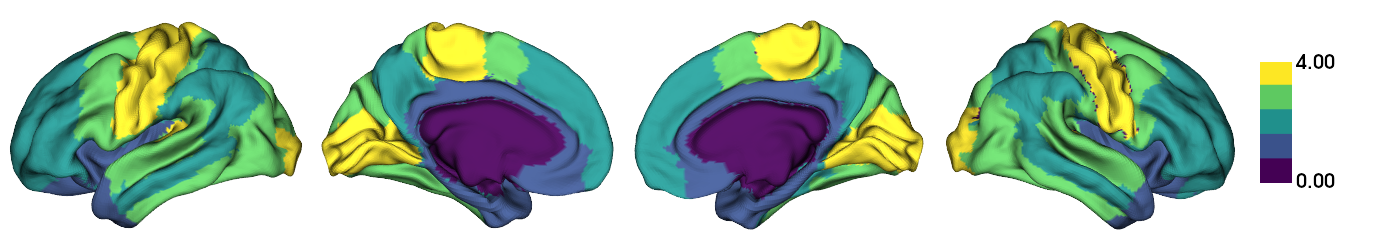

In [5]:
#mesu_32k_round = mesu_32k_round.astype(float)
#mesu_32k_round[mask_32k == False] = np.nan

# plot labels on surface
plot_hemispheres(f32k_lh, f32k_rh, mesu_32k_round, cmap='viridis', nan_color=(0.3, 0.3, 0.3, 1),
                      zoom=1.5, size=(1400, 250), embed_nb=True,
                      color_bar='right', cb__labelTextProperty={"fontSize": 20})

## Von Economo classes

In [6]:
ecoL_32k =  nib.load('/host/percy/local_raid/youngeun/from_mica1/parc/economo_fsLR32k.L.shape.gii').darrays[0].data
ecoR_32k =  nib.load('/host/percy/local_raid/youngeun/from_mica1/parc/economo_fsLR32k.R.shape.gii').darrays[0].data
eco_32k = np.concatenate((ecoL_32k, ecoR_32k), axis=0)
eco_32k_round = np.round(eco_32k)

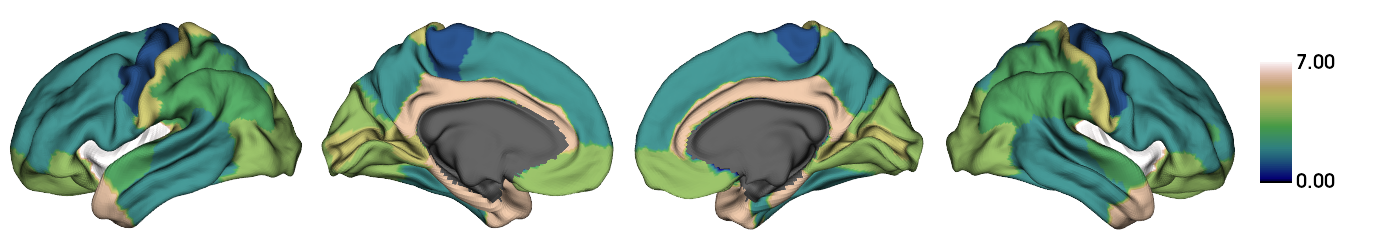

In [7]:
eco_32k_round[mask_32k == False] = np.nan

# plot labels on surface
plot_hemispheres(f32k_lh, f32k_rh, eco_32k_round, cmap='gist_earth', nan_color=(0.3, 0.3, 0.3, 1),
                      zoom=1.5, size=(1400, 250), embed_nb=True,
                      color_bar='right', cb__labelTextProperty={"fontSize": 20})

In [8]:
def masked_zscore(data, mask):
    out = np.full_like(data, np.nan, dtype=float)
    out[mask] = zscore(data[mask], nan_policy='omit')   
    return out

In [9]:
# ------------------------------------------------------
# 1) Difference maps (Δ = parallel – perpendicular)
# ------------------------------------------------------
dAFD = AFD_par - AFD_perp
dFA = FA_par - FA_perp
dMD = MD_par - MD_perp
dCS = CS_par - CS_perp

# ------------------------------------------------------
# 2) Z-score normalization
# ------------------------------------------------------
dAFD_z = masked_zscore(dAFD, mask_32k)
dFA_z = masked_zscore(dFA, mask_32k)
dMD_z = masked_zscore(dMD, mask_32k)
dCS_z = masked_zscore(dCS, mask_32k)

## Difference map - AFD

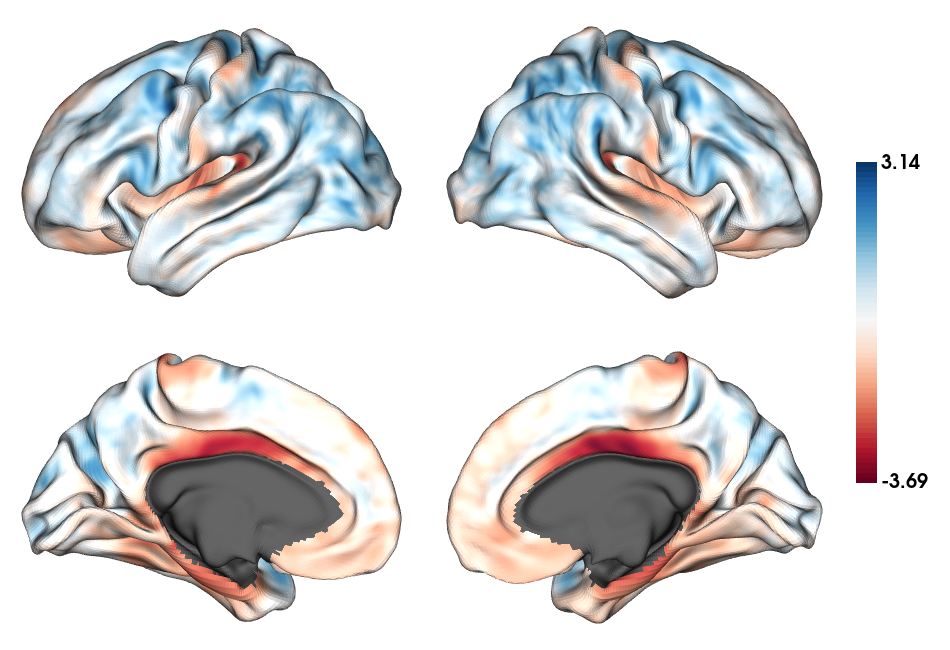

In [10]:
plot_hemispheres(f32k_lh, f32k_rh, array_name=dAFD_z, size=(950, 650), color_bar='right', zoom=1.5, embed_nb=True, interactive=False, share='both', nan_color=(0.3, 0.3, 0.3, 1), 
                 cmap='RdBu', layout_style='grid', transparent_bg=False, screenshot=False)

### Difference map - FA

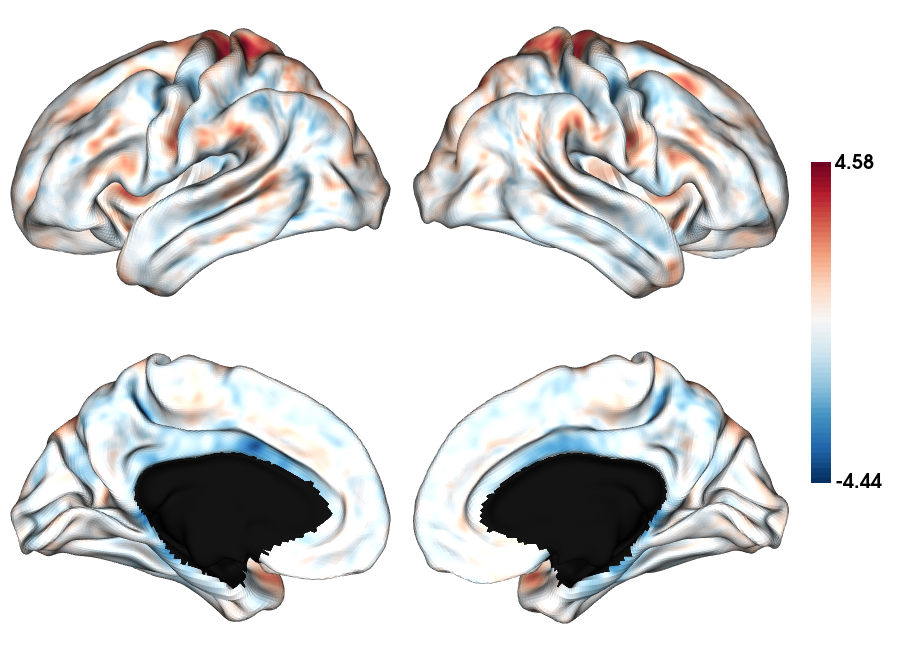

In [110]:
plot_hemispheres(f32k_lh, f32k_rh, array_name=dFA_z, size=(900, 650), color_bar='right', zoom=1.5, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='RdBu_r', layout_style='grid', transparent_bg=False, screenshot=False)

### Difference map - MD

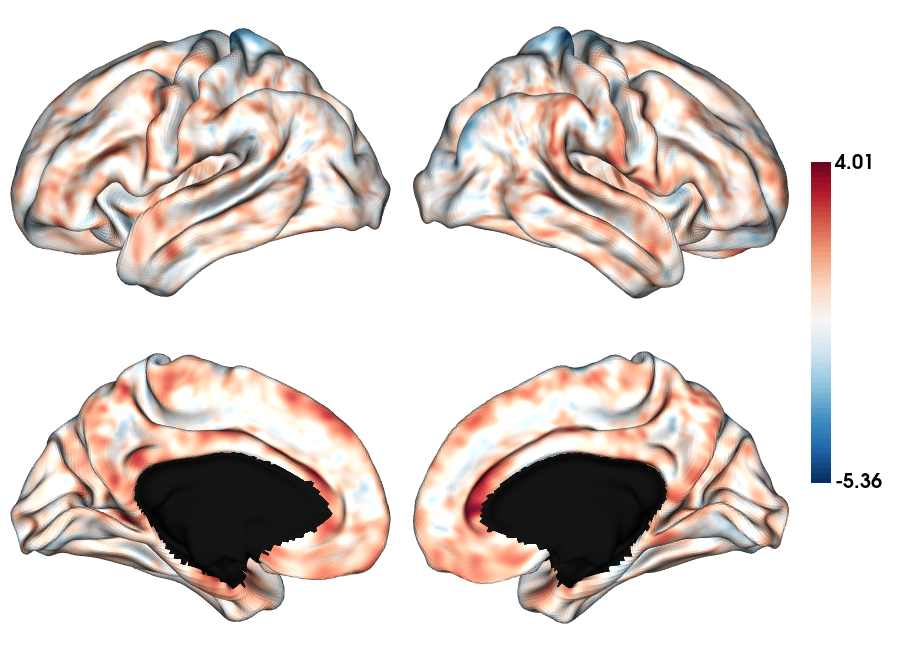

In [111]:
plot_hemispheres(f32k_lh, f32k_rh, array_name=dMD_z, size=(900, 650), color_bar='right', zoom=1.5, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='RdBu_r', layout_style='grid', transparent_bg=False, screenshot=False)

### Difference map - COMP SIZE

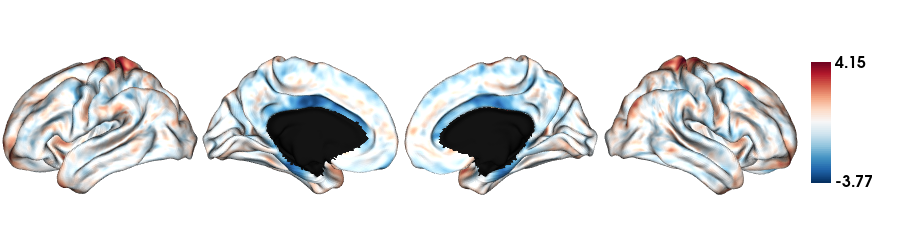

In [27]:
plot_hemispheres(f32k_lh, f32k_rh, array_name=dCS_z, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='RdBu_r', transparent_bg=False, screenshot=False)

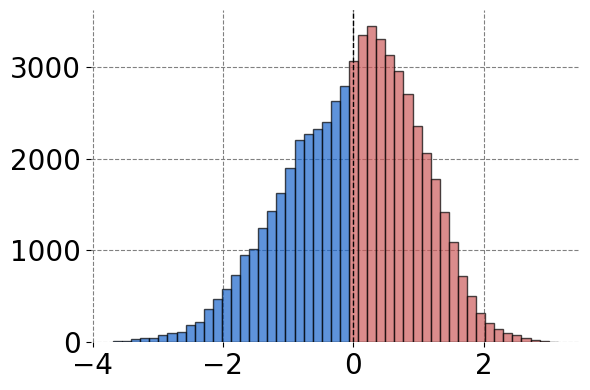

In [118]:
data = dAFD_z[~np.isnan(dAFD_z)]
bins = np.linspace(np.min(data), np.max(data), 50)
n, edges = np.histogram(data, bins=bins)
bin_centers = (edges[:-1] + edges[1:]) / 2

# 색상 지정
color_blue = '#1A66CC'
color_red  = '#CD5C5C'

# figure
plt.figure(figsize=(6,4))
ax = plt.gca()

# Set the grid on the back
plt.gca().set_axisbelow(True)
plt.grid(color='gray', linestyle='dashed')

# 0 이상 bar
mask_red = bin_centers > 0
plt.bar(bin_centers[mask_red], n[mask_red],
        width=np.diff(bin_centers)[0], color=color_red,
        edgecolor='black', alpha=0.7, label='Red > 0')

# 0 이하 bar
mask_blue = bin_centers < 0
plt.bar(bin_centers[mask_blue], n[mask_blue],
        width=np.diff(bin_centers)[0], color=color_blue,
        edgecolor='black', alpha=0.7, label='Blue < 0')

# 테두리 제거
for spine in ax.spines.values():
    spine.set_visible(False)

# labels & title
plt.xlabel("")
plt.ylabel("")
#plt.title("ΔAFD (z-scored) Distribution")

# y축 label size 조정
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)

# 0 기준 수직선
plt.axvline(0, color='k', linestyle='--', linewidth=1)

# legend
#plt.legend()

plt.tight_layout()
plt.show()

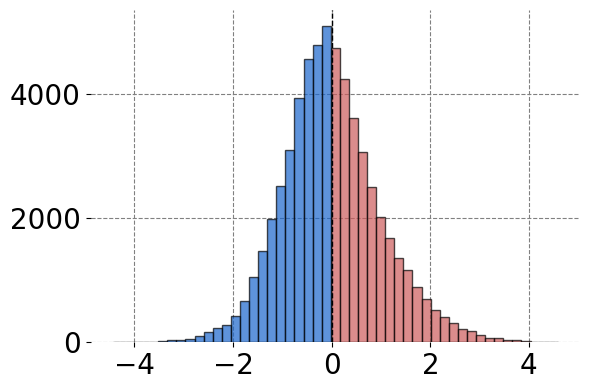

In [119]:
data = dFA_z[~np.isnan(dFA_z)]
bins = np.linspace(np.min(data), np.max(data), 50)
n, edges = np.histogram(data, bins=bins)
bin_centers = (edges[:-1] + edges[1:]) / 2

# 색상 지정
color_blue = '#1A66CC'
color_red  = '#CD5C5C'

# figure
plt.figure(figsize=(6,4))
ax = plt.gca()

# Set the grid on the back
plt.gca().set_axisbelow(True)
plt.grid(color='gray', linestyle='dashed')

# 0 이상 bar
mask_red = bin_centers > 0
plt.bar(bin_centers[mask_red], n[mask_red],
        width=np.diff(bin_centers)[0], color=color_red,
        edgecolor='black', alpha=0.7, label='Red > 0')

# 0 이하 bar
mask_blue = bin_centers < 0
plt.bar(bin_centers[mask_blue], n[mask_blue],
        width=np.diff(bin_centers)[0], color=color_blue,
        edgecolor='black', alpha=0.7, label='Blue < 0')

# 테두리 제거
for spine in ax.spines.values():
    spine.set_visible(False)

# labels & title
plt.xlabel("")
plt.ylabel("")
#plt.title("ΔFA (z-scored) Distribution")

# y축 label size 조정
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)

# 0 기준 수직선
plt.axvline(0, color='k', linestyle='--', linewidth=1)

# legend
#plt.legend()

plt.tight_layout()
plt.show()

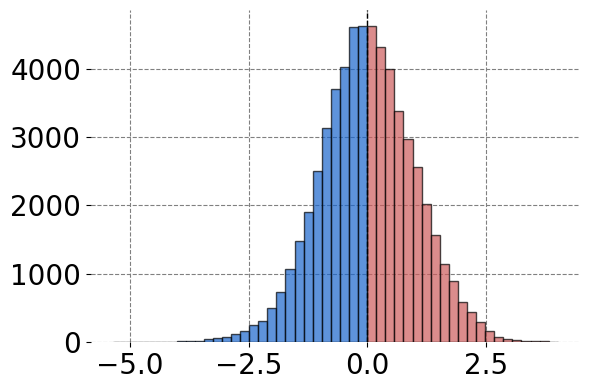

In [120]:
data = dMD_z[~np.isnan(dMD_z)]
bins = np.linspace(np.min(data), np.max(data), 50)
n, edges = np.histogram(data, bins=bins)
bin_centers = (edges[:-1] + edges[1:]) / 2

# 색상 지정
color_blue = '#1A66CC'
color_red  = '#CD5C5C'

# figure
plt.figure(figsize=(6,4))
ax = plt.gca()

# Set the grid on the back
plt.gca().set_axisbelow(True)
plt.grid(color='gray', linestyle='dashed')

# 0 이상 bar
mask_red = bin_centers > 0
plt.bar(bin_centers[mask_red], n[mask_red],
        width=np.diff(bin_centers)[0], color=color_red,
        edgecolor='black', alpha=0.7, label='Red > 0')

# 0 이하 bar
mask_blue = bin_centers < 0
plt.bar(bin_centers[mask_blue], n[mask_blue],
        width=np.diff(bin_centers)[0], color=color_blue,
        edgecolor='black', alpha=0.7, label='Blue < 0')

# 테두리 제거
for spine in ax.spines.values():
    spine.set_visible(False)

# labels & title
plt.xlabel("")
plt.ylabel("")
#plt.title("ΔMD (z-scored) Distribution")

# y축 label size 조정
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)

# 0 기준 수직선
plt.axvline(0, color='k', linestyle='--', linewidth=1)

# legend
#plt.legend()

plt.tight_layout()
plt.show()

In [68]:
# ------------------------------------------------------
# 3) Cytoarchitectonic class별 boxplot 데이터 준비
# ------------------------------------------------------
cyto = copy.deepcopy(mesu_32k_round)
classes = np.unique(cyto)
box_data_FA = [dFA_z[cyto == c] for c in classes]
box_data_MD = [dMD_z[cyto == c] for c in classes]

/tmp/ipykernel_1309946/782343981.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Class', y='ΔFA_z', data=df, palette=custom_palette, linewidth=2)


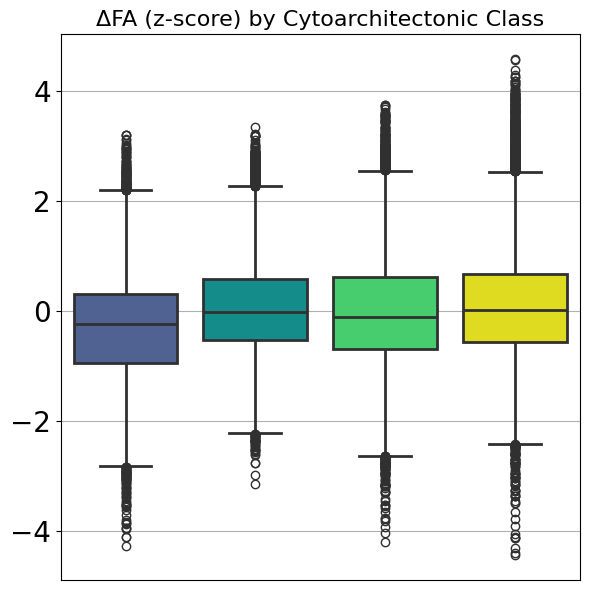

In [78]:
# --- DataFrame 준비 (예시) ---
data_for_plot = []
valid_classes = [1,2,3,4]
for val in valid_classes:
    class_mask = (cyto == val) & mask_32k
    class_values = dFA_z[class_mask]
    class_values = class_values[~np.isnan(class_values)]
    data_for_plot.extend([(val, v) for v in class_values])

df = pd.DataFrame(data_for_plot, columns=['Class', 'ΔFA_z'])

# --- 커스텀 색상 ---
custom_palette = ['#455d9c', '#00a09d', '#31e363', '#fffa00']

# --- Figure 생성 ---
plt.figure(figsize=(6,6))
ax = sns.boxplot(x='Class', y='ΔFA_z', data=df, palette=custom_palette, linewidth=2)

# x축 레이블 제거
ax.set_xlabel('')
ax.set_xticks([])
plt.ylabel('')

# y축 label size 조정
ax.tick_params(axis='y', labelsize=20)

# 배경 grid 추가
ax.grid(True)
ax.set_axisbelow(True)  # grid가 boxplot 뒤

# title
plt.title("ΔFA (z-score) by Cytoarchitectonic Class", fontsize=16)

plt.tight_layout()
plt.show()

In [86]:
# ------------------------------------------------------
# 3) Cytoarchitectonic class별 boxplot 데이터 준비
# ------------------------------------------------------
cyto = copy.deepcopy(eco_32k_round)
classes = np.unique(cyto)
box_data_FA = [dFA_z[cyto == c] for c in classes]
box_data_MD = [dMD_z[cyto == c] for c in classes]

/tmp/ipykernel_1309946/1678693867.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Class', y='ΔAFD_z', data=df, palette=custom_palette, linewidth=2)


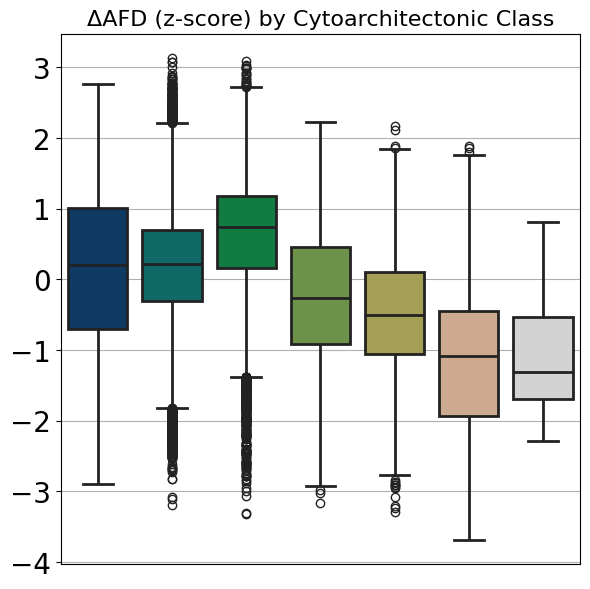

In [95]:
# --- DataFrame 준비 (예시) ---
data_for_plot = []
valid_classes = [1,2,3,4,5,6,7]
for val in valid_classes:
    class_mask = (cyto == val) & mask_32k
    class_values = dAFD_z[class_mask]
    class_values = class_values[~np.isnan(class_values)]
    data_for_plot.extend([(val, v) for v in class_values])

df = pd.DataFrame(data_for_plot, columns=['Class', 'ΔAFD_z'])

# --- 커스텀 색상 ---
custom_palette = ['#003b72ff', '#007874ff', '#008d41ff', '#6d9f3eff', '#b3aa47ff', '#d7a785ff', 'lightgray']

# --- Figure 생성 ---
plt.figure(figsize=(6,6))
ax = sns.boxplot(x='Class', y='ΔAFD_z', data=df, palette=custom_palette, linewidth=2)

# x축 레이블 제거
ax.set_xlabel('')
ax.set_xticks([])
plt.ylabel('')

# y축 label size 조정
ax.tick_params(axis='y', labelsize=20)

# 배경 grid 추가
ax.grid(True)
ax.set_axisbelow(True)  # grid가 boxplot 뒤

# title
plt.title("ΔAFD (z-score) by Cytoarchitectonic Class", fontsize=16)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1309946/1828451900.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Class', y='ΔFA_z', data=df, palette=custom_palette, linewidth=2)


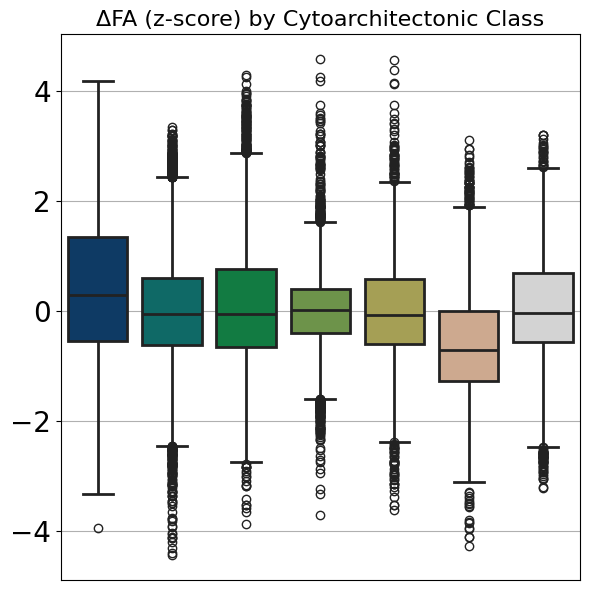

In [93]:
# --- DataFrame 준비 (예시) ---
data_for_plot = []
valid_classes = [1,2,3,4,5,6,7]
for val in valid_classes:
    class_mask = (cyto == val) & mask_32k
    class_values = dFA_z[class_mask]
    class_values = class_values[~np.isnan(class_values)]
    data_for_plot.extend([(val, v) for v in class_values])

df = pd.DataFrame(data_for_plot, columns=['Class', 'ΔFA_z'])

# --- 커스텀 색상 ---
custom_palette = ['#003b72ff', '#007874ff', '#008d41ff', '#6d9f3eff', '#b3aa47ff', '#d7a785ff', 'lightgray']

# --- Figure 생성 ---
plt.figure(figsize=(6,6))
ax = sns.boxplot(x='Class', y='ΔFA_z', data=df, palette=custom_palette, linewidth=2)

# x축 레이블 제거
ax.set_xlabel('')
ax.set_xticks([])
plt.ylabel('')

# y축 label size 조정
ax.tick_params(axis='y', labelsize=20)

# 배경 grid 추가
ax.grid(True)
ax.set_axisbelow(True)  # grid가 boxplot 뒤

# title
plt.title("ΔFA (z-score) by Cytoarchitectonic Class", fontsize=16)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1309946/3651584920.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Class', y='ΔMD_z', data=df, palette=custom_palette, linewidth=2)


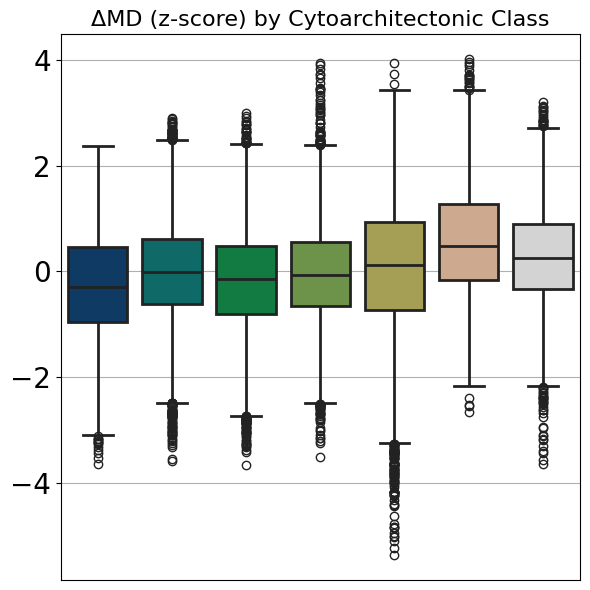

In [96]:
# --- DataFrame 준비 (예시) ---
data_for_plot = []
valid_classes = [1,2,3,4,5,6,7]
for val in valid_classes:
    class_mask = (cyto == val) & mask_32k
    class_values = dMD_z[class_mask]
    class_values = class_values[~np.isnan(class_values)]
    data_for_plot.extend([(val, v) for v in class_values])

df = pd.DataFrame(data_for_plot, columns=['Class', 'ΔMD_z'])

# --- 커스텀 색상 ---
custom_palette = ['#003b72ff', '#007874ff', '#008d41ff', '#6d9f3eff', '#b3aa47ff', '#d7a785ff', 'lightgray']

# --- Figure 생성 ---
plt.figure(figsize=(6,6))
ax = sns.boxplot(x='Class', y='ΔMD_z', data=df, palette=custom_palette, linewidth=2)

# x축 레이블 제거
ax.set_xlabel('')
ax.set_xticks([])
plt.ylabel('')

# y축 label size 조정
ax.tick_params(axis='y', labelsize=20)

# 배경 grid 추가
ax.grid(True)
ax.set_axisbelow(True)  # grid가 boxplot 뒤

# title
plt.title("ΔMD (z-score) by Cytoarchitectonic Class", fontsize=16)

plt.tight_layout()
plt.show()